# CMA-ES Optimization for Worst-Case OMWU Dynamics
This notebook demonstrates how to use the `CMAESGameOptimizer` to find payoff matrices that cause the Optimistic Multiplicative Weights Update (OMWU) algorithm to suffer maximum asymptotic regret in a 2-player, 2-action game.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.config.schemas import ExperimentConfig, GameConfig, DynamicConfig, ExecutionConfig, CMAESConfig
from src.engine.optimizer import CMAESGameOptimizer
from src.engine.runner import ExperimentRunner
from src.engine.statistics import load_experiment_stats

# Set formatting for plots
plt.style.use('ggplot')


## 1. Configure the Optimizer
We configure a 2x2 game base template and set the CMA-ES optimizer to target the `delta_reg` objective. This helps us find games where the algorithm continues to diverge or cycle heavily even late into the simulation.


In [2]:
# Setup a small configuration for 2x2 games
# We use a batch size of 20 to run 20 games in parallel per generation
population_size = 20

config = ExperimentConfig(
    name="cmaes_omwu_demo",
    game=GameConfig(
        generator="custom",
        utility_range=(-1.0, 1.0),
        payoffs=[
            [[1.0, 0.5], [0.5, 1.0]], # Player 1 base
            [[1.0, -1.0], [0.5, 1.0]], # Player 2 base
        ]
    ),
    dynamic=DynamicConfig(
        algorithm="omwu", 
        eta=0.05
    ),
    execution=ExecutionConfig(
        total_steps=200000,
        batch_size=population_size,
        steps_per_call=200, 
        device="auto",
        dtype="float64", # Run CMA-ES in double precision to avoid numerical artifacts!
        compile=True
    ),
    cmaes=CMAESConfig(
        sigma=0.3,
        seed=42,
        objective_type="delta_reg",
        T1_ratio=0.8,
        lambda_reg=0.5
    )
)

# Initialize CMA-ES Optimizer
# T1_ratio = 0.5 means we compute delta regret from step 500 to 1000
optimizer = CMAESGameOptimizer(
    base_config=config
)


## 2. Run the Optimization
We run the optimizer for a few generations (e.g., 5). In a real experiment, you might run this for 50-100 generations.


In [3]:
# Run optimization
best_payoffs, best_regret = optimizer.optimize(generations=5)

print("Optimization Complete!")
print(f"Worst-case Regret Found: {best_regret:.4f}")
print("\nWorst-case Payoff Matrix Player 1:")
print(np.round(best_payoffs[0].numpy(), 4))
print("\nWorst-case Payoff Matrix Player 2:")
print(np.round(best_payoffs[1].numpy(), 4))


Output()

Optimization Complete!
Worst-case Regret Found: 51.1738

Worst-case Payoff Matrix Player 1:
[[-0.1408  0.1628]
 [-0.139  -0.1397]]

Worst-case Payoff Matrix Player 2:
[[ 0.0726 -0.574 ]
 [-0.5175 -0.1687]]


## 2.5 Reloading Past Optimization Results
Because CMA-ES optimizations can take a long time, the `CMAESGameOptimizer` automatically saves the best matrices and config at the end of `optimize()` to `outputs/cmaes_best_{session_id}.pt`. 

You can easily reload these exact tensors later using the static `load_results` method!

In [ ]:
# The session_id was generated during initialization
session_id = optimizer.session_id

# We can load the exact dict saved to disk
saved_data = CMAESGameOptimizer.load_results(session_id)

# Verify it matches perfectly
assert torch.allclose(best_payoffs[0], saved_data["payoffs"][0])
print(f"Successfully reloaded results for session {session_id}!")

# To load from a completely past run, you would just type:
# past_data = CMAESGameOptimizer.load_results("1a2b3c4d")
# best_payoffs = past_data["payoffs"]

## 3. Simulate the Worst-Case Game
Now we plug these worst-case matrices back into a standard `ExperimentRunner` and run a longer, high-fidelity simulation (e.g. 5000 steps) to see what the dynamics look like.


In [4]:
import copy

# Create a validation config with the worst-case matrices
val_config = copy.deepcopy(config)
val_config.dynamic.eta = 0.005
val_config.game.payoffs = [p.numpy().tolist() for p in best_payoffs]
val_config.execution.batch_size = 1
val_config.execution.total_steps = 800000
val_config.execution.steps_per_call = 500
val_config.name = "worst_case_omwu"

# Run the single simulation
runner = ExperimentRunner(val_config)
summary = runner.run()

print(f"Validation Run Complete. Session ID: {summary['session_id']}")


[08/03/26 13:29:00] INFO     Enabling PyTorch JIT compilation via torch.compile(backend='cudagraphs')...

                    INFO     Starting simulation 'worst_case_omwu' [Session: 044c470a-faf8-47df-8c11-a678724b7b2d] 
                             on device 'cuda' for T=800000 steps.

Output()

[08/03/26 13:33:13] INFO     Simulation completed cleanly! Final Max Avg Regret: 0.000801. Stats session ID        
                             '044c470a-faf8-47df-8c11-a678724b7b2d' in 'outputs'

Validation Run Complete. Session ID: 044c470a-faf8-47df-8c11-a678724b7b2d


## 4. Plot the Trajectories
We extract the cumulative regret and strategy probabilities using `load_experiment_stats` and visualize the non-converging dynamics.


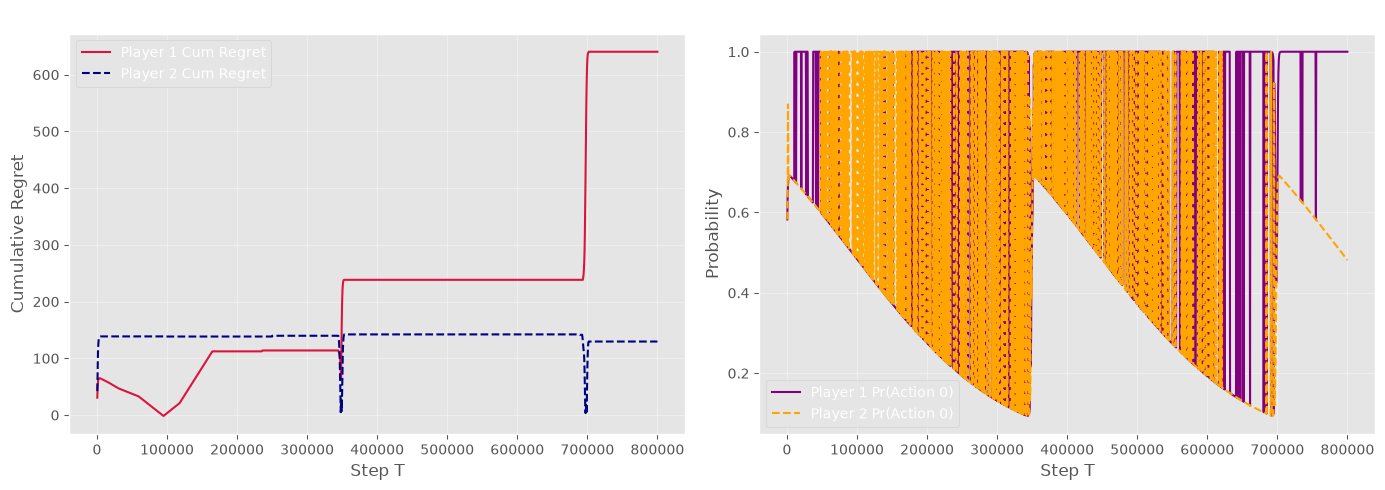

In [5]:
from src.engine.statistics import unpack_stats
from src.utils.visualization import plot_static_trajectories

# Load and unpack the recorded statistics from disk
stats_data = load_experiment_stats(output_dir=output_dir, session_id=session_id)
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

# Plot the static N-player trajectories (Zoom in by setting start_step and end_step if desired!)
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
fig, axes = plot_static_trajectories(steps, cum_regrets, strats, title_prefix="OMWU", plot_all_actions=False, start_step=0, end_step=None, cum_action_payoffs=cum_action_payoffs, cum_expected_payoffs=cum_expected_payoffs)
plt.show()


In [6]:
from torchdiffeq import odeint
import time
from dynamics.continuous import OMWUContinuous

payoffs = runner.game.get_payoff_tensors()
U1 = payoffs[0].squeeze(0) if payoffs[0].dim() == 3 else payoffs[0]
U2 = payoffs[1].squeeze(0) if payoffs[1].dim() == 3 else payoffs[1]
A1, A2 = U1.shape

emp_eta = runner.dynamic.eta
total_steps = runner.config.execution.total_steps

if isinstance(emp_eta, torch.Tensor):
    emp_eta = emp_eta.item()

dyn = OMWUContinuous(U1, U2, emp_eta)
state0 = torch.zeros(2*A1 + 2*A2 + 2, device='cuda')
T = total_steps * emp_eta
t = torch.linspace(0, T, total_steps, device='cuda')

torch.cuda.synchronize() if torch.cuda.is_available() else None
t0_ode = time.time()

# Run ODE forward pass
states = odeint(dyn, state0, t, method='dopri5')

torch.cuda.synchronize() if torch.cuda.is_available() else None
t1_ode = time.time()
ode_time = t1_ode - t0_ode

# Extract continuous regret trajectory
idx = A1 + A2
Z1_traj = states[:, idx : idx+A1]; idx += A1
P1_traj = states[:, idx : idx+1]; idx += 1
Z2_traj = states[:, idx : idx+A2]; idx += A2
P2_traj = states[:, idx : idx+1]

continuous_regret_p1 = (Z1_traj.max(dim=1).values - P1_traj.squeeze(1)).cpu().numpy()
continuous_regret_p2 = (Z2_traj.max(dim=1).values - P2_traj.squeeze(1)).cpu().numpy()



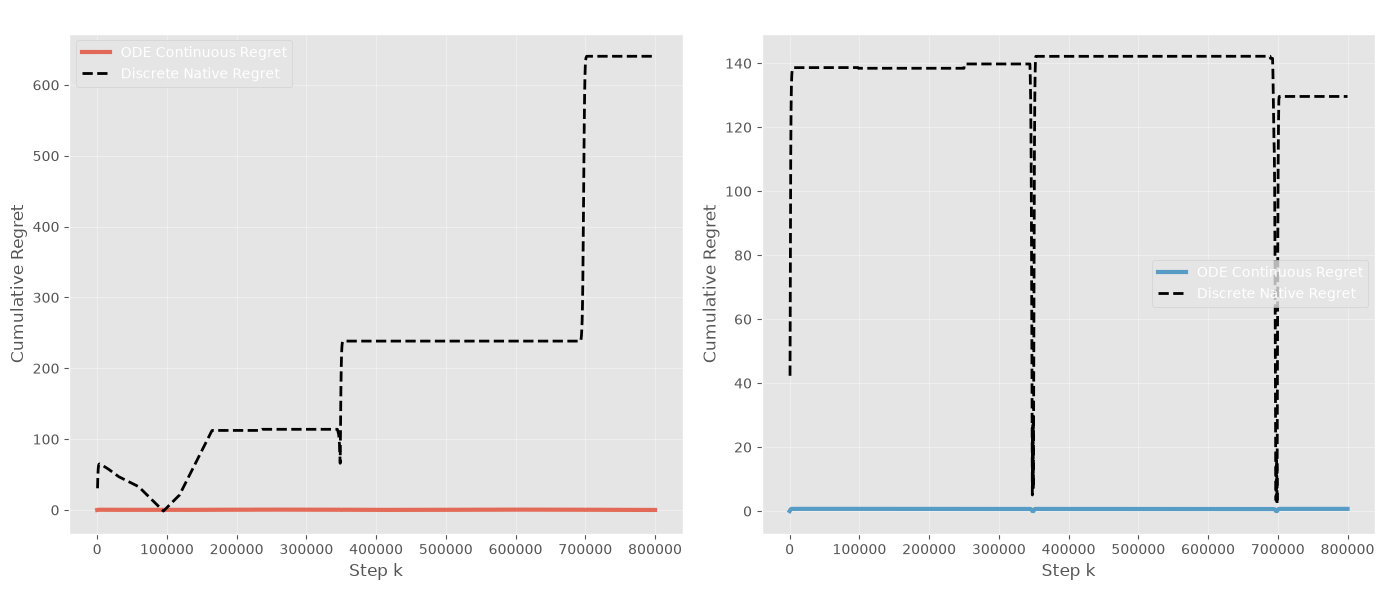

In [7]:
from src.engine.statistics import unpack_stats
from src.utils.visualization import plot_static_trajectories

# Load and unpack the recorded statistics from disk
stats_data = load_experiment_stats(output_dir=output_dir, session_id=session_id)
steps, cum_regrets, strats, logits, instant_payoffs = unpack_stats(stats_data)

# Plot the static N-player trajectories (Zoom in by setting start_step and end_step if desired!)
import torch
cum_action_payoffs = [torch.cumsum(p, dim=0) for p in instant_payoffs]
cum_expected_payoffs = [torch.cumsum(torch.sum(s * p, dim=-1), dim=0) for s, p in zip(strats, instant_payoffs)]
fig, axes = plot_static_trajectories(steps, cum_regrets, strats, title_prefix="OMWU", plot_all_actions=False, start_step=0, end_step=None, cum_action_payoffs=cum_action_payoffs, cum_expected_payoffs=cum_expected_payoffs)
plt.show()
